# Analisis de resultados

Este notebook consume los datos generados por `generador_de_datos.ipynb` y organiza la parte analitica de la entrega.

En esta etapa el flujo experimental activo corresponde a `gradiente`, y los datos se leen desde:

- `gradiente/datos/<funcion>/`

La idea es que este notebook concentre:
- presentacion del analisis
- carga general de datos
- visualizacion de funciones matematicas
- resultados experimentales
- figuras y tablas para el reporte
- mas adelante, animaciones finales


## 1. Presentacion del notebook

Este notebook esta pensado para crecer por bloques, pero con una estructura estable para las 6 funciones del proyecto:

- Rosenbrock
- Schwefel
- Rastrigin
- Griewank
- Goldstein-Price
- Six-Hump Camel

Notas metodologicas:
- por ahora el analisis experimental activo corresponde a gradiente
- `Goldstein-Price` y `Six-Hump Camel` se visualizan en 2D porque en el proyecto se manejan en su forma clasica bidimensional
- las formulas matematicas y gradientes ya quedaron documentados en `reporte_estructura.md`, asi que aqui no se duplican como teoria extensa; se usan como apoyo a la visualizacion


In [36]:
import ast
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE_DIR = Path.cwd()
PROJECT_DIR = BASE_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))

from funciones_objetivo import (
    goldstein_price,
    griewank,
    rastrigin,
    rosenbrock,
    schwefel,
    six_hump_camel,
)

DATA_DIR = BASE_DIR / "datos"
MANIFEST_PATH = DATA_DIR / "manifest_gradiente.json"
REPORTE_PATH = PROJECT_DIR / "reporte_estructura.md"

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "No se encontro la carpeta datos dentro de gradiente. Ejecuta primero generador_de_datos.ipynb."
    )

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        "No se encontro manifest_gradiente.json. Ejecuta primero generador_de_datos.ipynb."
    )

if not REPORTE_PATH.exists():
    raise FileNotFoundError(
        "No se encontro reporte_estructura.md."
    )


## 2. Carga general de datos

En esta seccion se cargan las corridas disponibles y los resumenes por funcion.

La estructura esperada es:

- `datos/rosenbrock/`
- `datos/schwefel/`
- `datos/rastrigin/`
- `datos/griewank/`
- `datos/goldstein_price/`
- `datos/six_hump_camel/`


In [37]:
with MANIFEST_PATH.open("r", encoding="utf-8") as file:
    manifest = json.load(file)

manifest

{'bloque': 1,
 'funciones': ['rosenbrock', 'schwefel', 'rastrigin'],
 'consumer_notebook': '02_analisis_resultados.ipynb',
 'descripcion': 'Datos generados sin graficas ni animaciones.',
 'filtros_ejecucion': {'selected_functions': ['rosenbrock',
   'schwefel',
   'rastrigin'],
  'selected_dimensions': [2, 3],
  'selected_n_corridas': [100, 500],
  'skip_existing_files': True},
 'directorios': {'datos_base': 'gradiente/datos'},
 'organizacion_corridas': 'gradiente/datos/<funcion>/<archivo>.json|csv',
 'organizacion_resumenes': 'gradiente/datos/<funcion>/resumen_<funcion>.json|csv',
 'campos_corridas': ['funcion',
  'nombre_funcion',
  'corrida',
  'semilla',
  'metodo',
  'dimension',
  'limites',
  'posicion_inicial',
  'posicion_final',
  'valor_final',
  'iteraciones',
  'evaluaciones',
  'parametros'],
 'campos_resumen': ['funcion',
  'nombre_funcion',
  'metodo',
  'dimension',
  'n_corridas',
  'mejor_valor_final',
  'peor_valor_final',
  'promedio_valor_final',
  'mediana_valor_

In [38]:
run_files = sorted(path for path in DATA_DIR.glob("*/*.csv") if not path.name.startswith("resumen_"))
summary_files = sorted(DATA_DIR.glob("*/resumen_*.csv"))

if not run_files:
    raise FileNotFoundError(
        "No se encontraron archivos de corridas dentro de datos/<funcion>/."
    )

runs_df = pd.concat((pd.read_csv(path) for path in run_files), ignore_index=True)

if summary_files:
    summary_df = pd.concat((pd.read_csv(path) for path in summary_files), ignore_index=True)
else:
    summary_df = (
        runs_df.groupby(["funcion", "nombre_funcion", "metodo", "dimension"], dropna=False)
        .agg(
            n_corridas=("corrida", "count"),
            mejor_valor_final=("valor_final", "min"),
            peor_valor_final=("valor_final", "max"),
            promedio_valor_final=("valor_final", "mean"),
            mediana_valor_final=("valor_final", "median"),
            desviacion_valor_final=("valor_final", "std"),
            promedio_evaluaciones=("evaluaciones", "mean"),
            mediana_evaluaciones=("evaluaciones", "median"),
            promedio_iteraciones=("iteraciones", "mean"),
            mediana_iteraciones=("iteraciones", "median"),
        )
        .reset_index()
    )
    summary_df["desviacion_valor_final"] = summary_df["desviacion_valor_final"].fillna(0.0)


In [39]:
print("Archivos de corridas encontrados:", len(run_files))
print("Archivos de resumen encontrados:", len(summary_files))

run_files

Archivos de corridas encontrados: 12
Archivos de resumen encontrados: 3


[WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/rastrigin/rastrigin_gradient_2d_n100.csv'),
 WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/rastrigin/rastrigin_gradient_2d_n500.csv'),
 WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/rastrigin/rastrigin_gradient_3d_n100.csv'),
 WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/rastrigin/rastrigin_gradient_3d_n500.csv'),
 WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/rosenbrock/rosenbrock_gradient_2d_n100.csv'),
 WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/rosenbrock/rosenbrock_gradient_2d_n500.csv'),
 WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/

In [40]:
runs_df.head()

,funcion,nombre_funcion,corrida,semilla,metodo,dimension,limites,posicion_inicial,posicion_final,valor_final,iteraciones,evaluaciones,parametros
0,rastrigin,Rastrigin,1,2140,gradient,2,"[-5.12, 5.12]","[2.7755954831752785, -1.2794610618200308]","[2.98485501995408, -0.9949596166466498]",9.949560,26,28,"{""max_iterations"": 1000, ""rate"": 0.001, ""toler..."
1,rastrigin,Rastrigin,2,2141,gradient,2,"[-5.12, 5.12]","[-1.4773613777785513, 1.140116327784754]","[-0.9949598205120276, 0.994958653274631]",1.989918,32,34,"{""max_iterations"": 1000, ""rate"": 0.001, ""toler..."
2,rastrigin,Rastrigin,3,2142,gradient,2,"[-5.12, 5.12]","[-4.474197270769645, 3.6131978824550055]","[-3.9797849426974716, 3.9797834971498567]",31.838488,31,33,"{""max_iterations"": 1000, ""rate"": 0.001, ""toler..."
3,rastrigin,Rastrigin,4,2143,gradient,2,"[-5.12, 5.12]","[1.4664437868033504, -4.205838849394761]","[0.9949598622460826, -3.979783911186147]",16.914203,31,33,"{""max_iterations"": 1000, ""rate"": 0.001, ""toler..."
4,rastrigin,Rastrigin,5,2144,gradient,2,"[-5.12, 5.12]","[0.6118463151021514, -2.7410940323531907]","[0.9949574320422145, -2.984855363250247]",9.949560,28,30,"{""max_iterations"": 1000, ""rate"": 0.001, ""toler..."


In [41]:
summary_df

,funcion,nombre_funcion,metodo,dimension,n_corridas,mejor_valor_final,peor_valor_final,promedio_valor_final,mediana_valor_final,desviacion_valor_final,promedio_evaluaciones,mediana_evaluaciones,promedio_iteraciones,mediana_iteraciones
0,rastrigin,Rastrigin,gradient,2,100,1.989918,40.792967,22.446131,24.873723,10.328634,29.040,28.0,27.040,26.0
1,rastrigin,Rastrigin,gradient,2,500,0.994959,40.792967,17.043546,16.914203,10.538270,28.854,28.0,26.854,26.0
2,rastrigin,Rastrigin,gradient,3,100,1.989918,58.702047,31.947931,35.320801,13.037185,30.100,30.0,28.100,28.0
3,rastrigin,Rastrigin,gradient,3,500,1.989918,58.702047,22.706825,21.391534,12.308730,31.920,31.0,29.920,29.0
4,rosenbrock,Rosenbrock,gradient,2,500,0.000185,5.648255,1.494395,0.745529,1.645576,1002.000,1002.0,1000.000,1000.0
5,rosenbrock,Rosenbrock,gradient,3,500,0.086961,4.792868,2.022777,1.873292,1.169810,1002.000,1002.0,1000.000,1000.0
6,schwefel,Schwefel,gradient,2,500,-15.320704,1225.634336,430.805149,401.595103,317.567768,10002.000,10002.0,10000.000,10000.0
7,schwefel,Schwefel,gradient,3,500,-7.734811,1450.156384,650.606775,660.483984,354.563288,10002.000,10002.0,10000.000,10000.0


## 3. Visualizacion de funciones matematicas

En esta seccion se dejan reunidas las 6 funciones del trabajo con una visualizacion uniforme.

Criterio de presentacion:
- la definicion matematica y el gradiente ya estan consignados en `reporte_estructura.md`
- aqui se busca apoyo visual, no repetir toda la teoria
- se reutiliza el estilo de graficacion visto en el notebook de Catalina: una vista 3D y una vista de contorno en la misma figura


In [42]:
def evaluate_on_grid(f, X1, X2):
    try:
        Z = f(np.array([X1, X2]))
        Z = np.asarray(Z)
        if Z.ndim == 2:
            return Z
    except Exception:
        pass

    return np.vectorize(lambda a, b: f(np.array([a, b], dtype=float)))(X1, X2)


def plot_function_course_style(
    f,
    x1_range,
    x2_range,
    title="Function Plot",
    x1_point=None,
    x2_point=None,
    elev=30,
    azim=45,
    grid_size=400,
):
    x1 = np.linspace(x1_range[0], x1_range[1], grid_size)
    x2 = np.linspace(x2_range[0], x2_range[1], grid_size)
    X1, X2 = np.meshgrid(x1, x2)
    Z = evaluate_on_grid(f, X1, X2)

    fig = plt.figure(figsize=(14, 6))

    ax1 = fig.add_subplot(121, projection="3d")
    ax1.plot_surface(X1, X2, Z, alpha=0.9, edgecolor="none")
    ax1.set_title(f"3D Plot of {title}")
    ax1.set_xlabel("X1")
    ax1.set_ylabel("X2")
    ax1.set_zlabel("Z")
    ax1.view_init(elev=elev, azim=azim)

    if x1_point is not None and x2_point is not None:
        z_point = f(np.array([x1_point, x2_point]))
        ax1.plot(
            [x1_point],
            [x2_point],
            [z_point],
            color="r",
            marker="o",
            markersize=5,
            linewidth=0,
            label="Minimo global",
            zorder=5,
        )
        ax1.legend()

    ax2 = fig.add_subplot(122)
    contour = ax2.contour(X1, X2, Z)
    ax2.set_title(f"Contour Plot of {title}")
    ax2.set_xlabel("X1")
    ax2.set_ylabel("X2")
    fig.colorbar(contour, ax=ax2)

    if x1_point is not None and x2_point is not None:
        ax2.plot(
            [x1_point],
            [x2_point],
            color="r",
            marker="o",
            markersize=5,
            linewidth=0,
            label="Minimo global",
            zorder=5,
        )
        ax2.legend()

    plt.tight_layout()
    plt.show()


In [43]:
ACTIVE_FUNCTIONS_IN_DATA = set(runs_df["funcion"].dropna().astype(str).unique())

FUNCTION_VISUAL_CONFIGS = {
    "rosenbrock": {
        "display_name": "Rosenbrock",
        "function": rosenbrock,
        "x1_range": (-2.0, 2.0),
        "x2_range": (-1.0, 3.0),
        "point": (1.0, 1.0),
        "active_in_data": "rosenbrock" in ACTIVE_FUNCTIONS_IN_DATA,
        "notes": "Activa cuando existan archivos en gradiente/datos/rosenbrock/.",
    },
    "schwefel": {
        "display_name": "Schwefel",
        "function": schwefel,
        "x1_range": (-500.0, 500.0),
        "x2_range": (-500.0, 500.0),
        "point": (420.9687, 420.9687),
        "active_in_data": "schwefel" in ACTIVE_FUNCTIONS_IN_DATA,
        "notes": "Activa cuando existan archivos en gradiente/datos/schwefel/.",
    },
    "rastrigin": {
        "display_name": "Rastrigin",
        "function": rastrigin,
        "x1_range": (-5.12, 5.12),
        "x2_range": (-5.12, 5.12),
        "point": (0.0, 0.0),
        "active_in_data": "rastrigin" in ACTIVE_FUNCTIONS_IN_DATA,
        "notes": "Activa cuando existan archivos en gradiente/datos/rastrigin/.",
    },
    "griewank": {
        "display_name": "Griewank",
        "function": griewank,
        "x1_range": (-10.0, 10.0),
        "x2_range": (-10.0, 10.0),
        "point": (0.0, 0.0),
        "active_in_data": "griewank" in ACTIVE_FUNCTIONS_IN_DATA,
        "notes": "Activa cuando existan archivos en gradiente/datos/griewank/.",
    },
    "goldstein_price": {
        "display_name": "Goldstein-Price",
        "function": goldstein_price,
        "x1_range": (-2.0, 2.0),
        "x2_range": (-2.0, 2.0),
        "point": (0.0, -1.0),
        "active_in_data": "goldstein_price" in ACTIVE_FUNCTIONS_IN_DATA,
        "notes": "Visualizacion 2D clasica. Activa cuando existan archivos en gradiente/datos/goldstein_price/.",
    },
    "six_hump_camel": {
        "display_name": "Six-Hump Camel",
        "function": six_hump_camel,
        "x1_range": (-2.0, 2.0),
        "x2_range": (-1.5, 1.5),
        "point": (0.0898, -0.7126),
        "active_in_data": "six_hump_camel" in ACTIVE_FUNCTIONS_IN_DATA,
        "notes": "Visualizacion 2D clasica. Activa cuando existan archivos en gradiente/datos/six_hump_camel/.",
    },
}

pd.DataFrame(
    [
        {
            "funcion": key,
            "nombre": value["display_name"],
            "activa_en_datos": value["active_in_data"],
            "nota": value["notes"],
        }
        for key, value in FUNCTION_VISUAL_CONFIGS.items()
    ]
)


,funcion,nombre,activa_en_datos,nota
0,rosenbrock,Rosenbrock,True,Bloque 1 activo en gradiente.
1,schwefel,Schwefel,True,Bloque 1 activo en gradiente.
2,rastrigin,Rastrigin,True,Activa cuando existan archivos en gradiente/da...
3,griewank,Griewank,False,Activa cuando existan archivos en gradiente/da...
4,goldstein_price,Goldstein-Price,False,Visualizacion 2D clasica. Activa cuando exista...
5,six_hump_camel,Six-Hump Camel,False,Visualizacion 2D clasica. Activa cuando exista...


### 3.1 Rosenbrock

Definicion y gradiente documentados en `reporte_estructura.md`.

En esta etapa:
- funcion activa en datos
- gradiente activo en experimentos


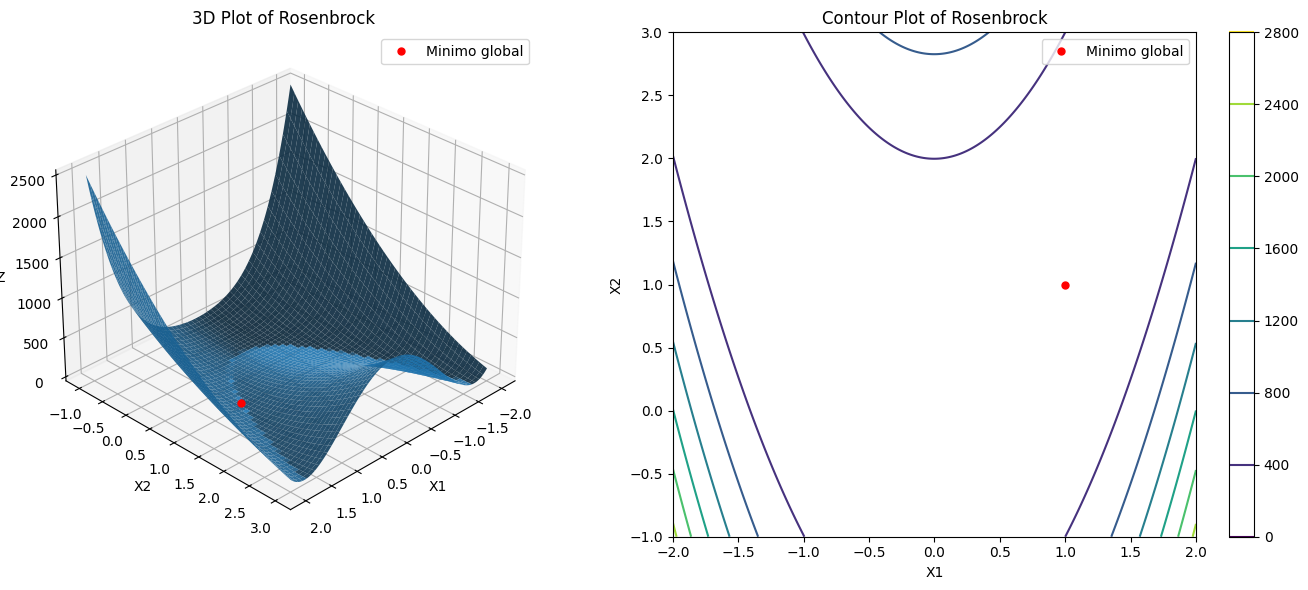

In [44]:
cfg = FUNCTION_VISUAL_CONFIGS["rosenbrock"]
plot_function_course_style(
    cfg["function"],
    cfg["x1_range"],
    cfg["x2_range"],
    title=cfg["display_name"],
    x1_point=cfg["point"][0],
    x2_point=cfg["point"][1],
)


#### Resultados de Rosenbrock

Tomando como base `02_corridas_rosenbrock.ipynb`, aqui se agregan las visualizaciones que mas aportan al analisis sin repetir la figura matematica de la funcion:

- histogramas de `valor_final` y `evaluaciones`
- dispersion de posiciones finales

No se replica el boxplot mixto de `valor_final` e `iteraciones`, porque mezcla escalas distintas y aporta menos lectura que los histogramas separados.


In [45]:
def add_run_count_from_filename(df: pd.DataFrame, file_paths: list[Path]) -> pd.DataFrame:
    file_map: dict[tuple[str, int], list[int]] = {}

    for path in file_paths:
        stem_parts = path.stem.split("_")
        if len(stem_parts) < 4:
            continue
        function_name = stem_parts[0]
        dimension_text = stem_parts[2]
        run_count_text = stem_parts[3]
        if not dimension_text.endswith("d") or not run_count_text.startswith("n"):
            continue
        dimension = int(dimension_text[:-1])
        run_count = int(run_count_text[1:])
        file_map.setdefault((function_name, dimension), []).append(run_count)

    enriched_frames: list[pd.DataFrame] = []
    for (function_name, dimension), counts in file_map.items():
        subset = df[(df["funcion"] == function_name) & (df["dimension"] == dimension)].copy()
        if subset.empty:
            continue
        counts = sorted(counts)
        start = 0
        for count in counts:
            end = min(start + count, len(subset))
            block = subset.iloc[start:end].copy()
            block["n_corridas_archivo"] = count
            enriched_frames.append(block)
            start = end

    if not enriched_frames:
        result = df.copy()
        result["n_corridas_archivo"] = np.nan
        return result

    return pd.concat(enriched_frames, ignore_index=True)


rosenbrock_runs = runs_df[runs_df["funcion"] == "rosenbrock"].copy()
rosenbrock_runs = add_run_count_from_filename(rosenbrock_runs, run_files)
rosenbrock_runs.head()


,funcion,nombre_funcion,corrida,semilla,metodo,dimension,limites,posicion_inicial,posicion_final,valor_final,iteraciones,evaluaciones,parametros,n_corridas_archivo
0,rosenbrock,Rosenbrock,1,2241,gradient,2,"[-2.048, 2.048]","[-0.5540941713164798, -0.1410404600453008]","[-0.13321867216795846, 0.020764167193429748]",1.285095,1000,1002,"{""max_iterations"": 1000, ""rate"": 0.0001, ""tole...",100
1,rosenbrock,Rosenbrock,2,2242,gradient,2,"[-2.048, 2.048]","[0.2748009795890791, 1.5598379525624781]","[0.9634805103327895, 0.9281453169477395]",0.001336,1000,1002,"{""max_iterations"": 1000, ""rate"": 0.0001, ""tole...",100
2,rosenbrock,Rosenbrock,3,2243,gradient,2,"[-2.048, 2.048]","[0.8808105271579567, 0.040167169444864204]","[0.5756766207495329, 0.32929853158384126]",0.180493,1000,1002,"{""max_iterations"": 1000, ""rate"": 0.0001, ""tole...",100
3,rosenbrock,Rosenbrock,4,2244,gradient,2,"[-2.048, 2.048]","[0.2425621304154424, 1.3371777755921954]","[0.8504491582173824, 0.7226099061389359]",0.022408,1000,1002,"{""max_iterations"": 1000, ""rate"": 0.0001, ""tole...",100
4,rosenbrock,Rosenbrock,5,2245,gradient,2,"[-2.048, 2.048]","[-0.4240872811137242, 1.48145414123766]","[-0.9320348836428229, 0.8767367178836597]",3.739235,1000,1002,"{""max_iterations"": 1000, ""rate"": 0.0001, ""tole...",100


In [46]:
rosenbrock_summary = summary_df[summary_df["funcion"] == "rosenbrock"].copy()
rosenbrock_summary = rosenbrock_summary.sort_values(["dimension", "n_corridas"]).reset_index(drop=True)
rosenbrock_summary[
    [
        "dimension",
        "n_corridas",
        "mejor_valor_final",
        "promedio_valor_final",
        "mediana_valor_final",
        "promedio_evaluaciones",
        "promedio_iteraciones",
    ]
]


,dimension,n_corridas,mejor_valor_final,promedio_valor_final,mediana_valor_final,promedio_evaluaciones,promedio_iteraciones
0,2,500,0.000185,1.494395,0.745529,1002.0,1000.0
1,3,500,0.086961,2.022777,1.873292,1002.0,1000.0


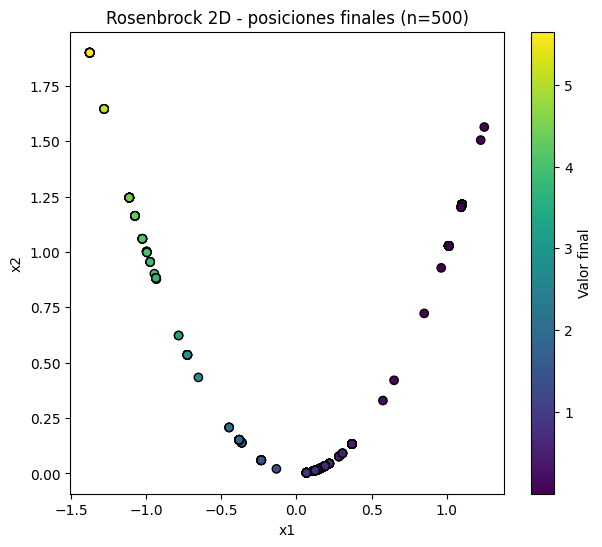

C:\Users\CARLOS\AppData\Local\Temp\ipykernel_22604\329902442.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


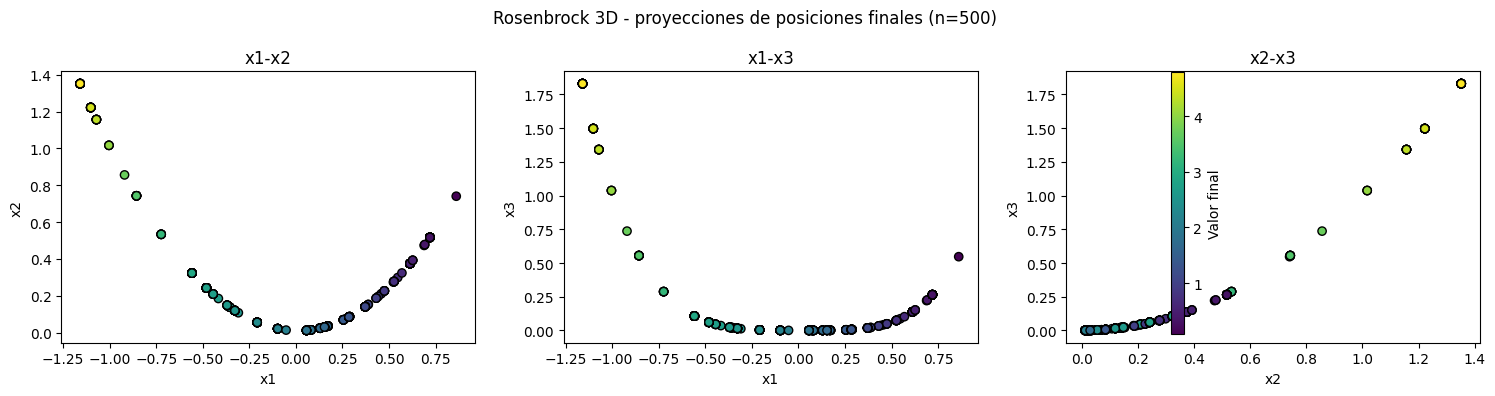

In [47]:
for dimension in sorted(rosenbrock_runs["dimension"].dropna().unique()):
    dimension_runs = rosenbrock_runs[rosenbrock_runs["dimension"] == dimension]
    if dimension_runs.empty:
        continue

    n_count = int(dimension_runs["n_corridas_archivo"].max())
    subset = dimension_runs[dimension_runs["n_corridas_archivo"] == n_count].copy()
    subset["posicion_final"] = subset["posicion_final"].apply(ast.literal_eval)
    final_positions = np.array(subset["posicion_final"].tolist(), dtype=float)
    final_values = subset["valor_final"].to_numpy(dtype=float)

    if dimension == 2:
        fig, ax = plt.subplots(figsize=(7, 6))
        scatter = ax.scatter(
            final_positions[:, 0],
            final_positions[:, 1],
            c=final_values,
            cmap="viridis",
            edgecolors="black",
        )
        ax.set_title(f"Rosenbrock 2D - posiciones finales (n={n_count})")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        fig.colorbar(scatter, ax=ax, label="Valor final")
        plt.show()
    elif dimension == 3:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        pairs = [(0, 1), (0, 2), (1, 2)]
        labels = [("x1", "x2"), ("x1", "x3"), ("x2", "x3")]

        for ax, (i, j), (xlabel, ylabel) in zip(axes, pairs, labels):
            scatter = ax.scatter(
                final_positions[:, i],
                final_positions[:, j],
                c=final_values,
                cmap="viridis",
                edgecolors="black",
            )
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)
            ax.set_title(f"{xlabel}-{ylabel}")

        fig.suptitle(f"Rosenbrock 3D - proyecciones de posiciones finales (n={n_count})")
        fig.colorbar(scatter, ax=axes, shrink=0.85, label="Valor final")
        fig.tight_layout()
        plt.show()


### 3.2 Schwefel

Definicion y gradiente documentados en `reporte_estructura.md`.

En esta etapa:
- funcion activa en datos
- gradiente activo en experimentos


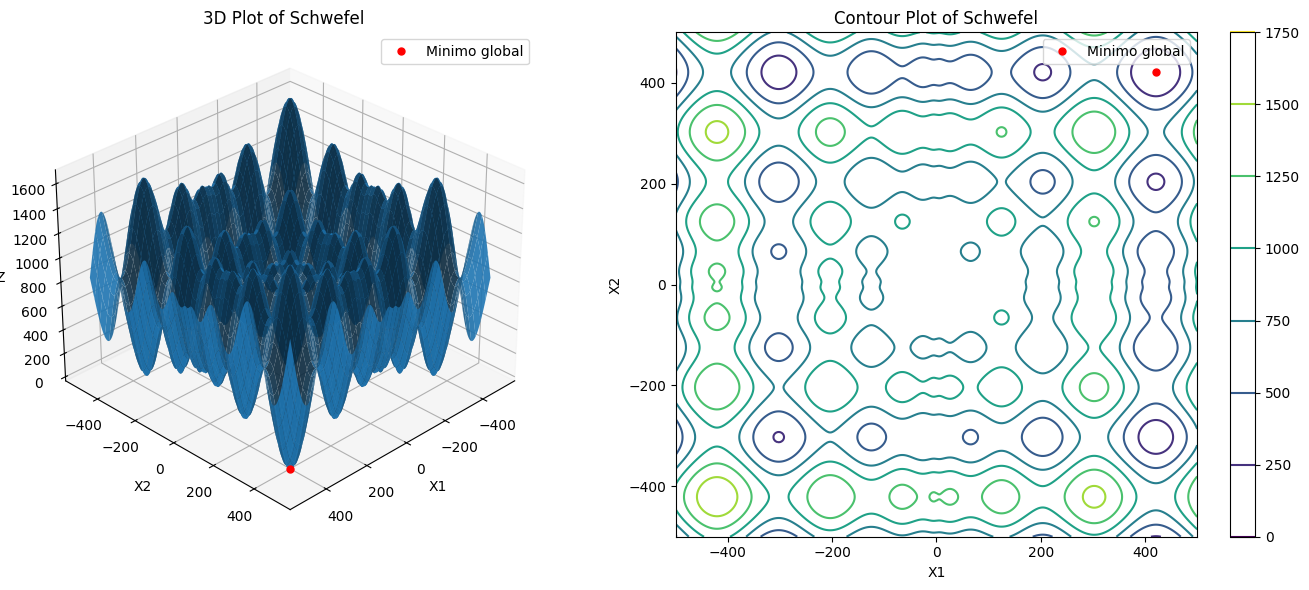

In [48]:
cfg = FUNCTION_VISUAL_CONFIGS["schwefel"]
plot_function_course_style(
    cfg["function"],
    cfg["x1_range"],
    cfg["x2_range"],
    title=cfg["display_name"],
    x1_point=cfg["point"][0],
    x2_point=cfg["point"][1],
)


### 3.3 Rastrigin

Definicion y gradiente documentados en `reporte_estructura.md`.

Estado actual:
- seccion preparada para Bloque 2


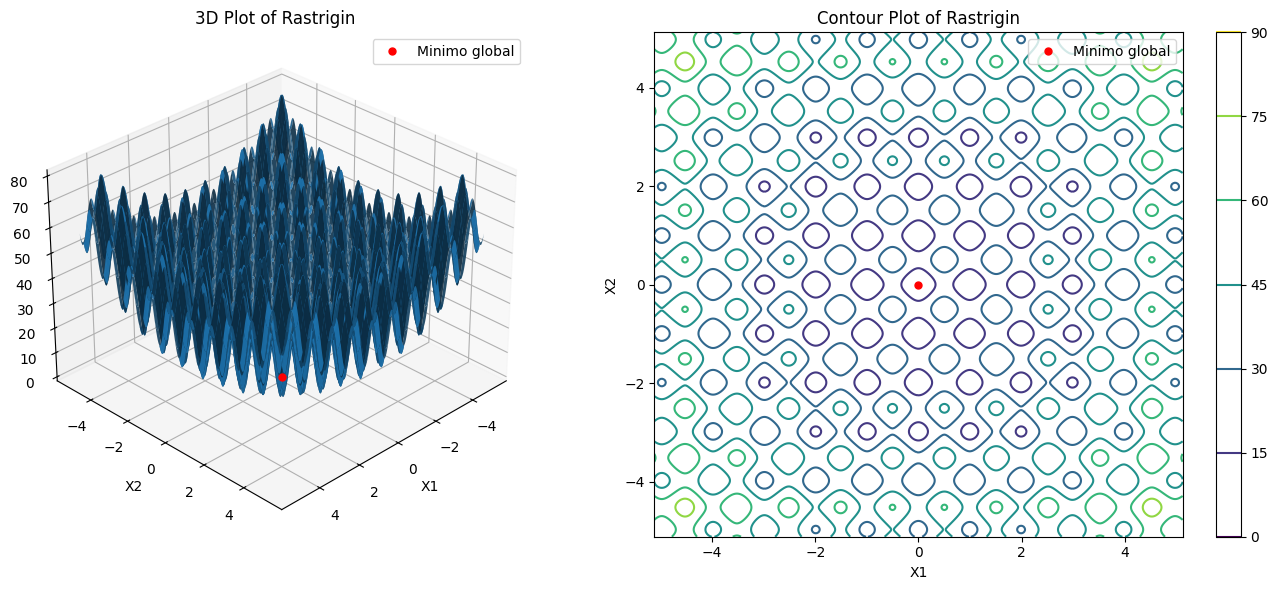

In [49]:
cfg = FUNCTION_VISUAL_CONFIGS["rastrigin"]
if cfg["active_in_data"]:
    plot_function_course_style(
        cfg["function"],
        cfg["x1_range"],
        cfg["x2_range"],
        title=cfg["display_name"],
        x1_point=cfg["point"][0],
        x2_point=cfg["point"][1],
    )
else:
    print(f"{cfg['display_name']} queda pendiente hasta que se generen sus datos experimentales.")


### 3.4 Griewank

Definicion y gradiente documentados en `reporte_estructura.md`.

Estado actual:
- seccion preparada para Bloque 2


In [50]:
cfg = FUNCTION_VISUAL_CONFIGS["griewank"]
if cfg["active_in_data"]:
    plot_function_course_style(
        cfg["function"],
        cfg["x1_range"],
        cfg["x2_range"],
        title=cfg["display_name"],
        x1_point=cfg["point"][0],
        x2_point=cfg["point"][1],
    )
else:
    print(f"{cfg['display_name']} queda pendiente hasta que se generen sus datos experimentales.")


Griewank queda pendiente hasta que se generen sus datos experimentales.


### 3.5 Goldstein-Price

Definicion y gradiente documentados en `reporte_estructura.md`.

Estado actual:
- seccion preparada para Bloque 3
- funcion visualizada en su forma bidimensional clasica


In [51]:
cfg = FUNCTION_VISUAL_CONFIGS["goldstein_price"]
if cfg["active_in_data"]:
    plot_function_course_style(
        cfg["function"],
        cfg["x1_range"],
        cfg["x2_range"],
        title=cfg["display_name"],
        x1_point=cfg["point"][0],
        x2_point=cfg["point"][1],
    )
else:
    print(f"{cfg['display_name']} queda pendiente hasta que se generen sus datos experimentales.")


Goldstein-Price queda pendiente hasta que se generen sus datos experimentales.


### 3.6 Six-Hump Camel

Definicion y gradiente documentados en `reporte_estructura.md`.

Estado actual:
- seccion preparada para Bloque 3
- funcion visualizada en su forma bidimensional clasica


In [52]:
cfg = FUNCTION_VISUAL_CONFIGS["six_hump_camel"]
if cfg["active_in_data"]:
    plot_function_course_style(
        cfg["function"],
        cfg["x1_range"],
        cfg["x2_range"],
        title=cfg["display_name"],
        x1_point=cfg["point"][0],
        x2_point=cfg["point"][1],
    )
else:
    print(f"{cfg['display_name']} queda pendiente hasta que se generen sus datos experimentales.")


Six-Hump Camel queda pendiente hasta que se generen sus datos experimentales.
